In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  # use GPU 1

from dingo.core.posterior_models.build_model import build_model_from_kwargs

main_pm = build_model_from_kwargs(
    filename="/scratch/tpausch/models/imbh_T2/model_latest.pt",
    device="cuda",
    load_training_info=False,
)



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.


In [23]:
%%capture
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset

injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)

cm=150.0

injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
asd_dataset = ASDDataset(file_name=asd_fname)
injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

intrinsic_parameters = {
    "chirp_mass": cm,
    "mass_ratio": 0.8,
    "a_1": .3,
    "a_2": .5,
    "tilt_1": 0.,
    "tilt_2": 0.,
    "phi_jl": 0.,
    "phi_12": 0.
}

extrinsic_parameters = {
    'phase': 0.,
    'theta_jn': 2.3,
    'geocent_time': 0.,
    'luminosity_distance': 1000_00.,
    'ra': 0.,
    'dec': 0.,
    'psi': 0.,
}

theta = {**intrinsic_parameters, **extrinsic_parameters}
strain_data = injection_generator.injection(theta)
# Returns dict with keys: 'waveform', 'parameters', 'extrinsic_parameters', 'asd'

from dingo.gw.inference.gw_samplers import  GWSampler
sampler =GWSampler(model=main_pm)
sampler.context = strain_data
sampler.run_sampler(num_samples=500_000, batch_size=10_000)
result = sampler.to_result()
#result.plot_corner(parameters=["chirp_mass", "mass_ratio", "luminosity_distance"])

In [24]:
import torch
del sampler.model  # or whatever holds the network on GPU
torch.cuda.empty_cache()

import lal
lal.ClobberDebugLevel(0)  # or whatever debug-level control your LAL version exposes

In [25]:
%%capture

result.importance_sample(
    num_processes=24,
    phase_marginalization_kwargs={},
)



Sample efficiency: 0.000
log Bayes factor: 85.94


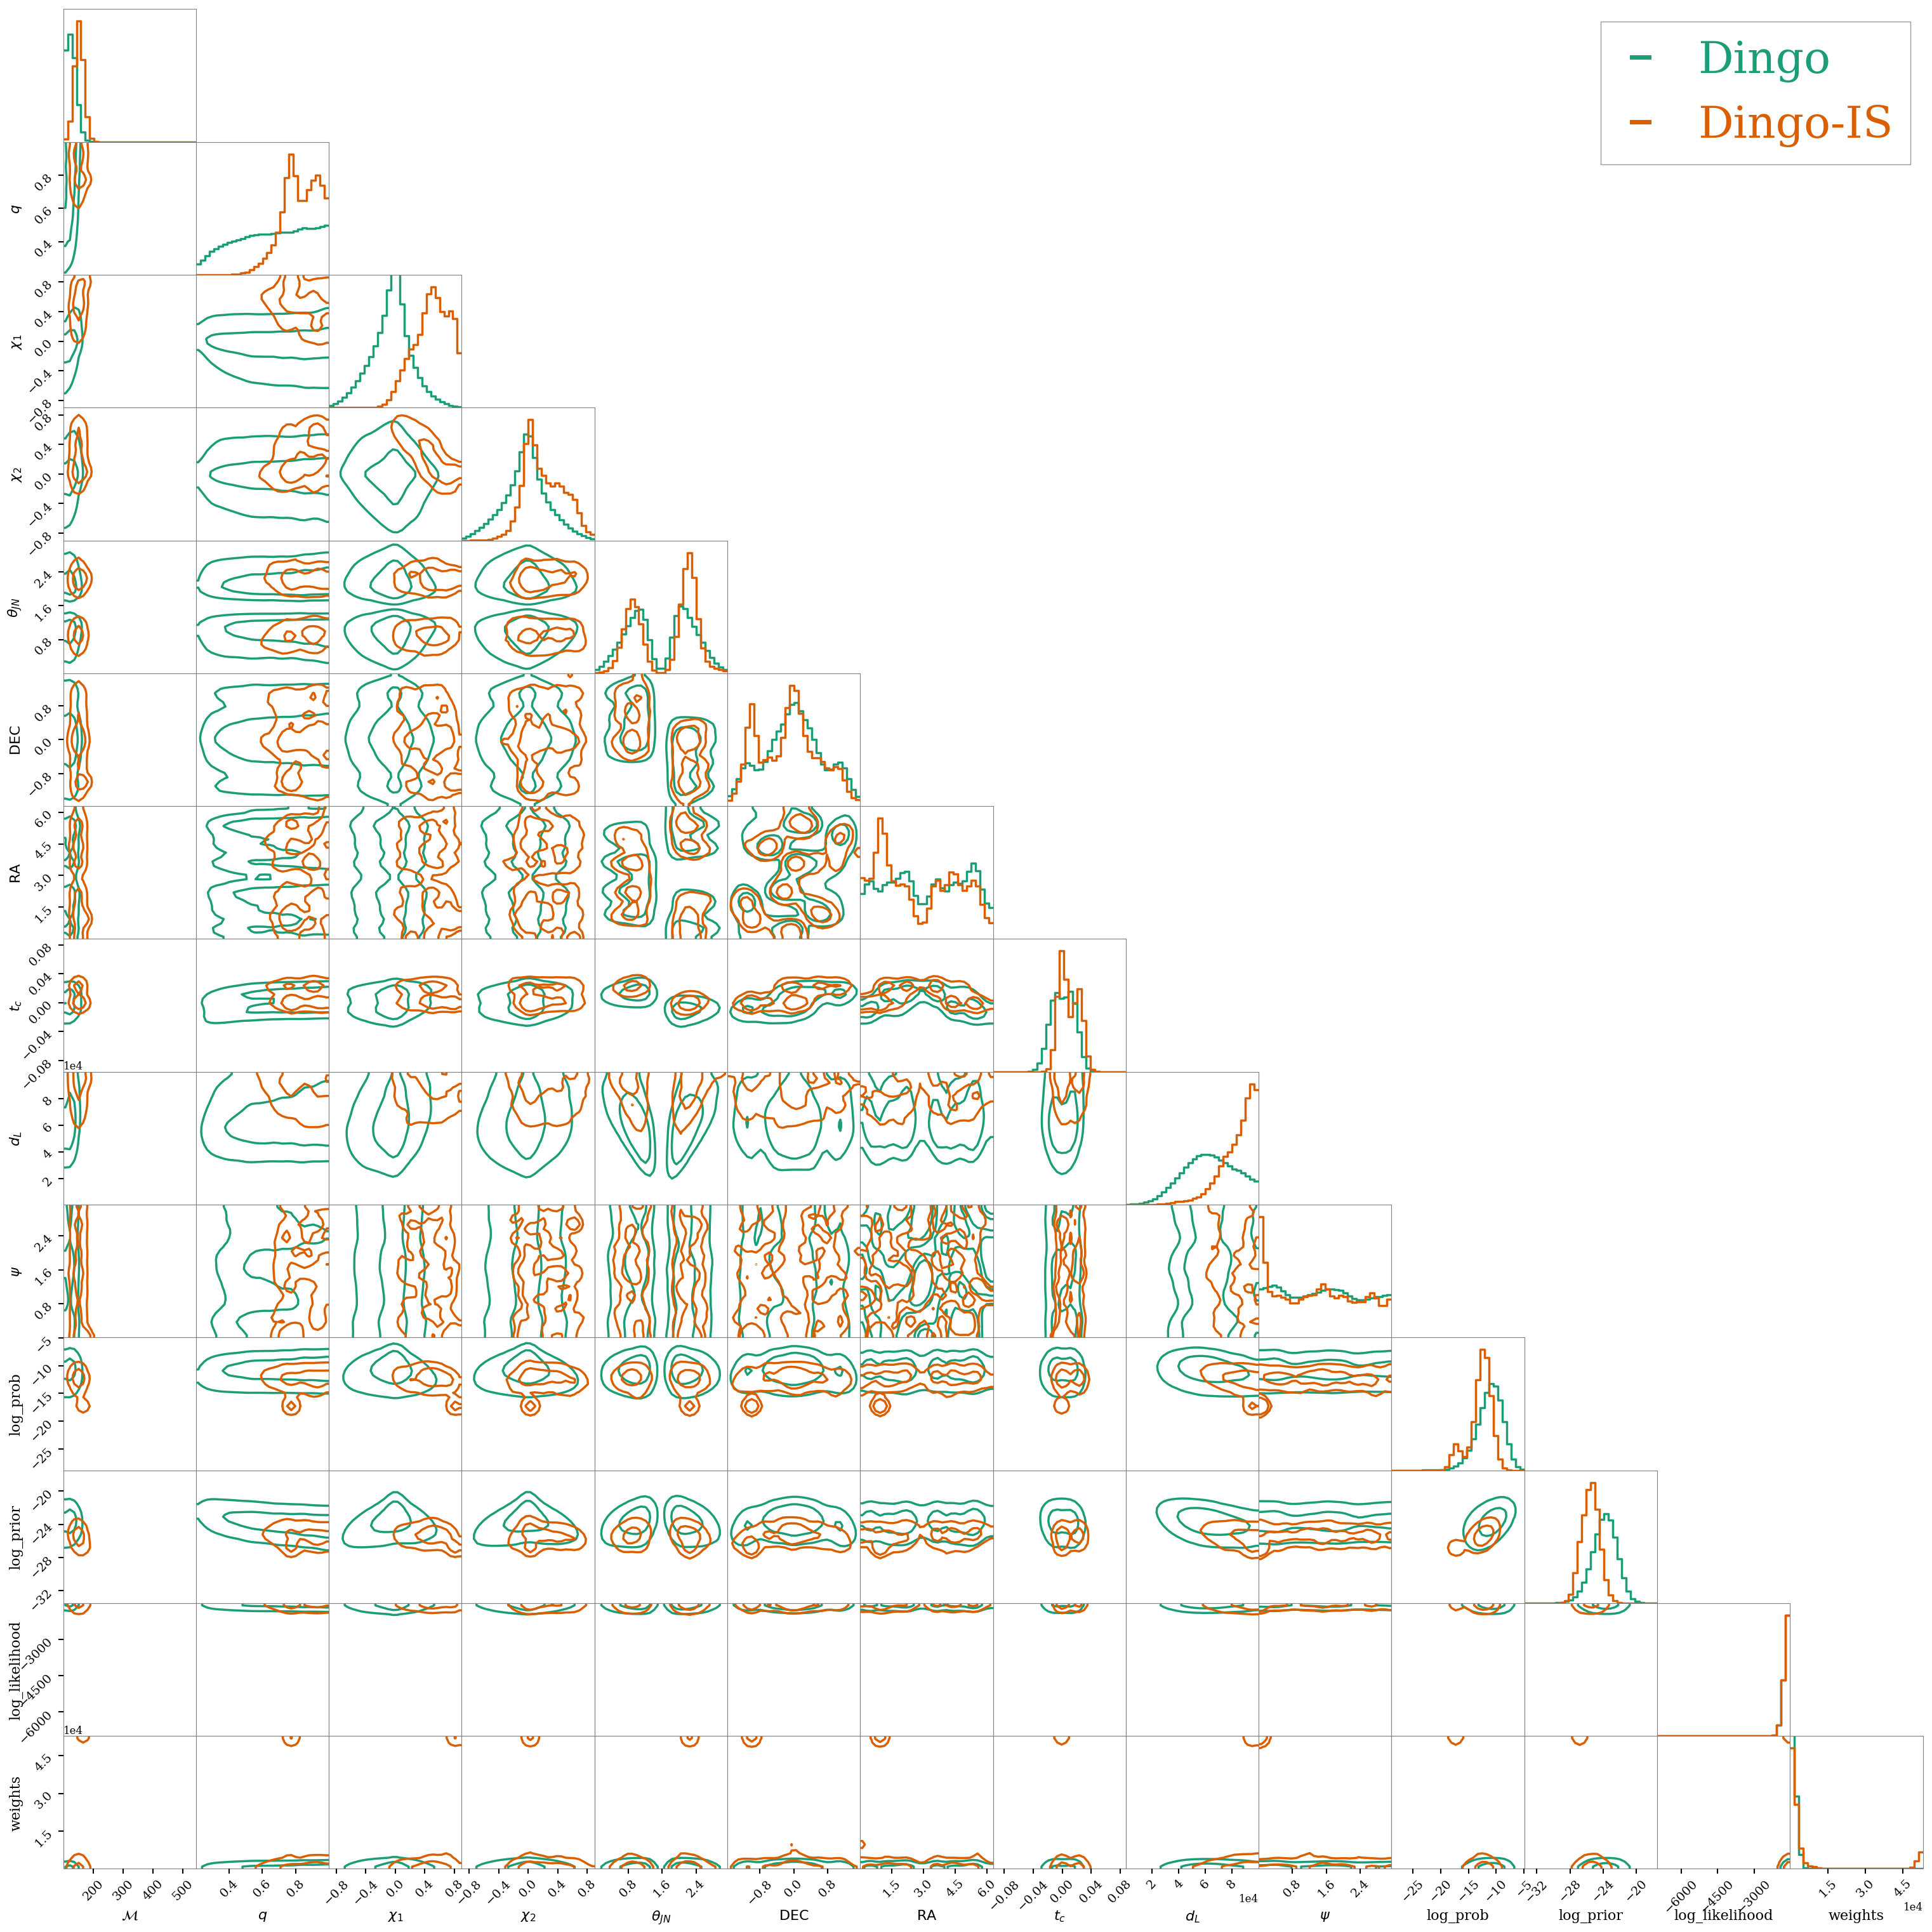

In [26]:
# These are now available after importance sampling:
print(f"Sample efficiency: {result.sample_efficiency:.3f}")  # ideally > ~10%
print(f"log Bayes factor: {result.log_bayes_factor:.2f}")

result.plot_corner()

In [10]:
print(result.samples.columns.tolist())

['chirp_mass', 'mass_ratio', 'chi_1', 'chi_2', 'theta_jn', 'dec', 'ra', 'geocent_time', 'luminosity_distance', 'psi', 'log_prob', 'log_prior', 'log_likelihood', 'weights']


In [11]:
samples = result.samples

log_prob = samples["log_prob"].values        # network proposal: log q(theta | d)
log_likelihood = samples["log_likelihood"].values  # exact likelihood: log L(d | theta)
log_prior = samples["log_prior"].values       # prior: log pi(theta)

log_weights = log_likelihood + log_prior - log_prob

In [12]:
import numpy as np
for name, arr in [("log_prob", log_prob), ("log_likelihood", log_likelihood), ("log_prior", log_prior)]:
    n_bad = np.sum(~np.isfinite(arr))
    print(f"{name}: {n_bad}/{len(arr)} non-finite, range=[{np.nanmin(arr):.1f}, {np.nanmax(arr):.1f}]")

log_prob: 0/50000 non-finite, range=[-23.8, -0.7]
log_likelihood: 10909/50000 non-finite, range=[-1962.8, -1534.7]
log_prior: 10909/50000 non-finite, range=[-inf, -19.5]


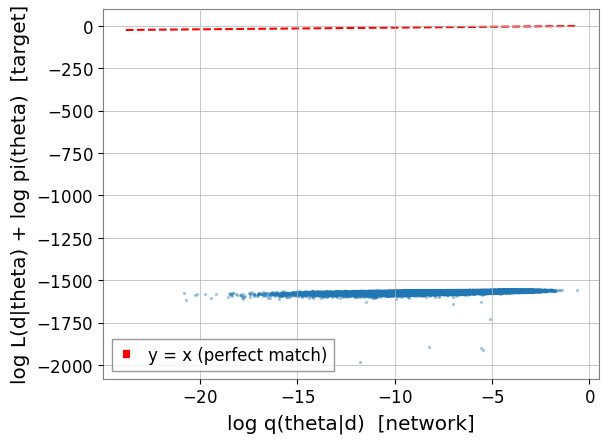

In [13]:
import matplotlib.pyplot as plt

target = log_likelihood + log_prior

plt.scatter(log_prob, target, s=2, alpha=0.3)
lims = [min(log_prob.min(), target.min()), max(log_prob.max(), target.max())]
plt.plot(lims, lims, 'r--', label='y = x (perfect match)')
plt.xlabel("log q(theta|d)  [network]")
plt.ylabel("log L(d|theta) + log pi(theta)  [target]")
plt.legend()

In [14]:
i_best = np.argmax(log_likelihood)
print("Best-fit sample (max log_likelihood):")
print(samples.iloc[i_best][["log_prob", "log_likelihood", "log_prior"]])
print(samples.iloc[i_best].drop(columns=["log_prob","log_likelihood","log_prior","weights"], errors="ignore"))

print("\nNetwork's typical log_prob:", np.median(log_prob), "vs log_prob at best-fit sample:", log_prob[i_best])

Best-fit sample (max log_likelihood):
log_prob         -4.21155
log_likelihood        NaN
log_prior            -inf
Name: 0, dtype: float64
chirp_mass             4.453002e+02
mass_ratio             5.893157e-01
chi_1                  2.852017e-01
chi_2                  3.710885e-02
theta_jn               2.550053e+00
dec                   -6.561198e-01
ra                     7.064400e-01
geocent_time           3.544322e-03
luminosity_distance    1.004174e+05
psi                    2.469441e+00
log_prob              -4.211550e+00
log_prior                      -inf
log_likelihood                  NaN
weights                0.000000e+00
Name: 0, dtype: float64

Network's typical log_prob: -6.6689644 vs log_prob at best-fit sample: -4.2115498


In [12]:
finite_mask = np.isfinite(log_likelihood) & np.isfinite(log_prior)
i_best = np.nanargmax(np.where(finite_mask, log_likelihood, np.nan))

print(samples.iloc[i_best][["log_prob", "log_likelihood", "log_prior"]])
print(samples.iloc[i_best].drop(columns=["log_prob","log_likelihood","log_prior","weights"], errors="ignore"))

log_prob           -14.503464
log_likelihood   -1395.500294
log_prior          -22.851897
Name: 30266, dtype: float64
chirp_mass               447.075134
mass_ratio                 0.758013
chi_1                      0.403471
chi_2                     -0.118095
theta_jn                   1.679400
dec                        0.029715
ra                         0.841434
geocent_time               0.020748
luminosity_distance    78467.890625
psi                        1.648528
log_prob                 -14.503464
log_prior                -22.851897
log_likelihood         -1395.500294
weights                  177.516558
Name: 30266, dtype: float64
